# 이진 분류 (Binary Classiflcation) 이란?

- 데이터를 두 개의 카테고리로 분류하는 문제<br>
- 딥러닝 모델이 밉력 데이터를 보고 해당 데이터가 "예(True)"인지, "아니오(False)"인지 판단<br>
<br>
- ex1) 스펨 email 분류
  - 입력 : 이메일 내용
  - 출력 : 스팸(1) 또는 정상(0)
<br>
- ex2) 질변 진단
  - 입력 : 환자의 건강 데이터
  - 출력 : 질병이 있음(1) 또는 질병이 없음(0)
<br>
- ex3) 합격 예측
   - 입력 : 학생의 점수
   - 출력 : 합격(1) 또는 불합격(0)

# 이진 분류 특징
- 출력 값 : 1 또는 0
- 활성화 함수 : 시그마모이드 함수 사용
- 손실 함수 : bring 뭐시기 사용

In [25]:
# 0단계 : 라이브러리 호출
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib
import platform

system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100


# 데이터 준비
->  학생들의 점수를 기반으로 합격/불합격 여부 예측


In [26]:
# 1단계 : 데이터 분비 (점수와 합격 여부)

np.random.seed(42)
X = np.random.randint(50,100,size=(100,10)) # 학생 점수 (50~100 사이의 정수 데이터로 생성)
y = (X>=75).astype(int)
# bool을 정수형 (int)로 변환, False는 0 ,True는 1

# 데이터 분리 (80는 학습 / 10은 테스트)
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=42)

# 데이터 시각화

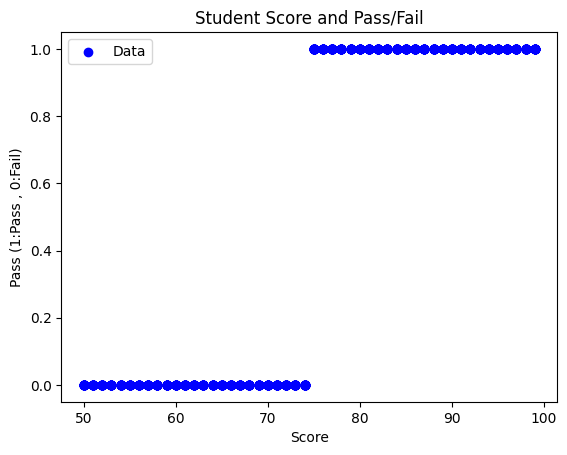

In [27]:
plt.scatter(X,y,color='blue',label='Data')
plt.xlabel('Score')
plt.ylabel('Pass (1:Pass , 0:Fail)')
plt.title('Student Score and Pass/Fail')
plt.legend()
plt.show()

# 모델 설계

In [43]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation='relu',input_shape=(10,)), # 은닉층
    tf.keras.layers.Dense(1,activation='sigmoid') # 출력층
])
model.summary() # 설계된 모델의 구조 출력

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

# 컴파일

In [44]:
# 손실 함수 , 옵티마이저 , 평가 지표 설정

model.compile(
    optimizer = 'adam',            # 효율적인 학습을 위한 옵티마이저 Adam
    loss = 'binary_crossentropy',  # 이진 분류를 위한 손실 함수
    metrics = ['accuracy']         # 학습 과정중 정확도 평가
)
print('컴파일 완료')

컴파일 완료


# 모델 학습

In [45]:
history = model.fit(
    X_train , y_train,
    epochs = 50,
    batch_size = 16,
    validation_split=0.2
)

Epoch 1/50


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(16, 10), output.shape=(16, 1)

# 모델 평가

In [46]:
# 예측
new_scores = np.array([[65],[80],[90]])
predictions = model.predict(new_scores)

# 예측 결과 출력
for  score , pred in zip(new_scores.flatten(),predictions.flatten()):
  print(
      f'점수 : {score} , \n'
      f'함겹률 예측 : {pred:.2f},\n'
      f"예측 결과 : {'합격' if pred > 0.5 else '불합격'}\n"
  )

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_18" is incompatible with the layer: expected axis -1 of input shape to have value 10, but received input with shape (3, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(3, 1), dtype=int64)
  • training=False
  • mask=None

In [42]:
# 학습 곡선의 시각화 (손실)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

NameError: name 'histroy' is not defined

In [ ]:
# 합학습 곡선 시각화 (정확도)
plt.plot(history)